In [27]:
with open("_chat.txt", encoding="utf-8") as f:
    lines = f.readlines()

lines[:20]

['[05.10.2024, 07:59:38] Компьютерное введение/КИ: \u200eСообщения и звонки защищены сквозным шифрованием. Прочитать, прослушать или переслать их могут только участники этого чата.\n',
 '[05.10.2024, 07:59:38] \u202a+7\xa0747\xa0637\xa00995\u202c: \u200eГруппа создана контактом \u202a+7\xa0747\xa0637\xa00995\u202c\n',
 '[28.01.2026, 08:11:41] Компьютерное введение/КИ: \u200e~\u202fNikita Qalan добавил(-а) вас\n',
 '\u200e[28.01.2026, 08:36:26] Куратор Байтенова С: КодексЧестиСтудента_2курсКН.docx • \u200e1 страница \u200eдокумент отсутствует\n',
 '[28.01.2026, 08:37:53] ~\u202f⠀\u200b: \u200e~\u202f⠀\u200b изменил(-а) картинку группы\n',
 '[28.01.2026, 08:40:57] ~\u202f⠀\u200b: \u200e~\u202f⠀\u200b удалил(-а) картинку группы\n',
 '[28.01.2026, 08:45:45] \u202a+7\xa0747\xa0699\xa04159\u202c: \u200e~\u202fNikita Qalan удалил(-а) контакт \u202a+7\xa0747\xa0699\xa04159\u202c\n',
 '[28.01.2026, 08:45:51] ~\u202faiya: \u200e~\u202fNikita Qalan добавил(-а) контакт ~\u202faiya\n',
 '\u200e[28.

In [28]:
import re
import pandas as pd

pattern = r'^\[(\d{2}\.\d{2}\.\d{4}, \d{2}:\d{2}:\d{2})\] (.*?): (.*)'

data = []

for line in lines:
    match = re.match(pattern, line)
    if match:
        date, user, msg = match.groups()
        data.append([date, user, msg])

df = pd.DataFrame(data, columns=["datetime","user","message"])
df.head()

,datetime,user,message
0,"05.10.2024, 07:59:38",Компьютерное введение/КИ,‎Сообщения и звонки защищены сквозным шифрован...
1,"05.10.2024, 07:59:38",‪+7 747 637 0995‬,‎Группа создана контактом ‪+7 747 637 0995‬
2,"28.01.2026, 08:11:41",Компьютерное введение/КИ,‎~ Nikita Qalan добавил(-а) вас
3,"28.01.2026, 08:37:53",~ ⠀​,‎~ ⠀​ изменил(-а) картинку группы
4,"28.01.2026, 08:40:57",~ ⠀​,‎~ ⠀​ удалил(-а) картинку группы


In [29]:
df.shape

(244, 3)

In [30]:
import re

def clean_text(text):
    text = text.lower()  # всё в нижний регистр
    text = re.sub(r'http\S+', '', text)  # убираем ссылки
    text = re.sub(r'[^\w\s]', '', text)  # убираем знаки препинания
    text = re.sub(r'\d+', '', text)      # убираем цифры
    text = text.replace('\u200e', '').replace('\u202a','').replace('\u202c','')  # специальные символы WhatsApp
    return text.strip()

df['clean'] = df['message'].apply(clean_text)
df.head(10)

,datetime,user,message,clean
0,"05.10.2024, 07:59:38",Компьютерное введение/КИ,‎Сообщения и звонки защищены сквозным шифрован...,сообщения и звонки защищены сквозным шифровани...
1,"05.10.2024, 07:59:38",‪+7 747 637 0995‬,‎Группа создана контактом ‪+7 747 637 0995‬,группа создана контактом
2,"28.01.2026, 08:11:41",Компьютерное введение/КИ,‎~ Nikita Qalan добавил(-а) вас,nikita qalan добавила вас
3,"28.01.2026, 08:37:53",~ ⠀​,‎~ ⠀​ изменил(-а) картинку группы,изменила картинку группы
4,"28.01.2026, 08:40:57",~ ⠀​,‎~ ⠀​ удалил(-а) картинку группы,удалила картинку группы
5,"28.01.2026, 08:45:45",‪+7 747 699 4159‬,‎~ Nikita Qalan удалил(-а) контакт ‪+7 747 699...,nikita qalan удалила контакт
6,"28.01.2026, 08:45:51",~ aiya,‎~ Nikita Qalan добавил(-а) контакт ~ aiya,nikita qalan добавила контакт aiya
7,"29.01.2026, 19:04:43",Куратор Байтенова С,Добрый вечер!,добрый вечер
8,"29.01.2026, 19:07:19",Куратор Байтенова С,❗️❗️❗️❗️❗️,
9,"29.01.2026, 19:08:06",Куратор Байтенова С,❗️❗️❗️❗️,


/tmp/ipykernel_32027/3738931703.py:9: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


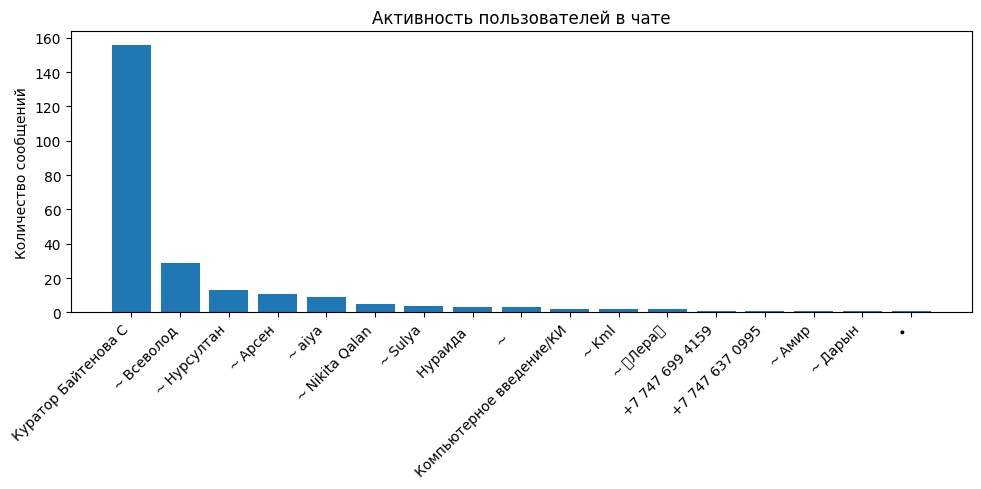

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
counts = df['user'].value_counts()
plt.bar(range(len(counts)), counts.values)
plt.xticks(range(len(counts)), counts.index, rotation=45, ha='right')
plt.ylabel('Количество сообщений')
plt.title('Активность пользователей в чате')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


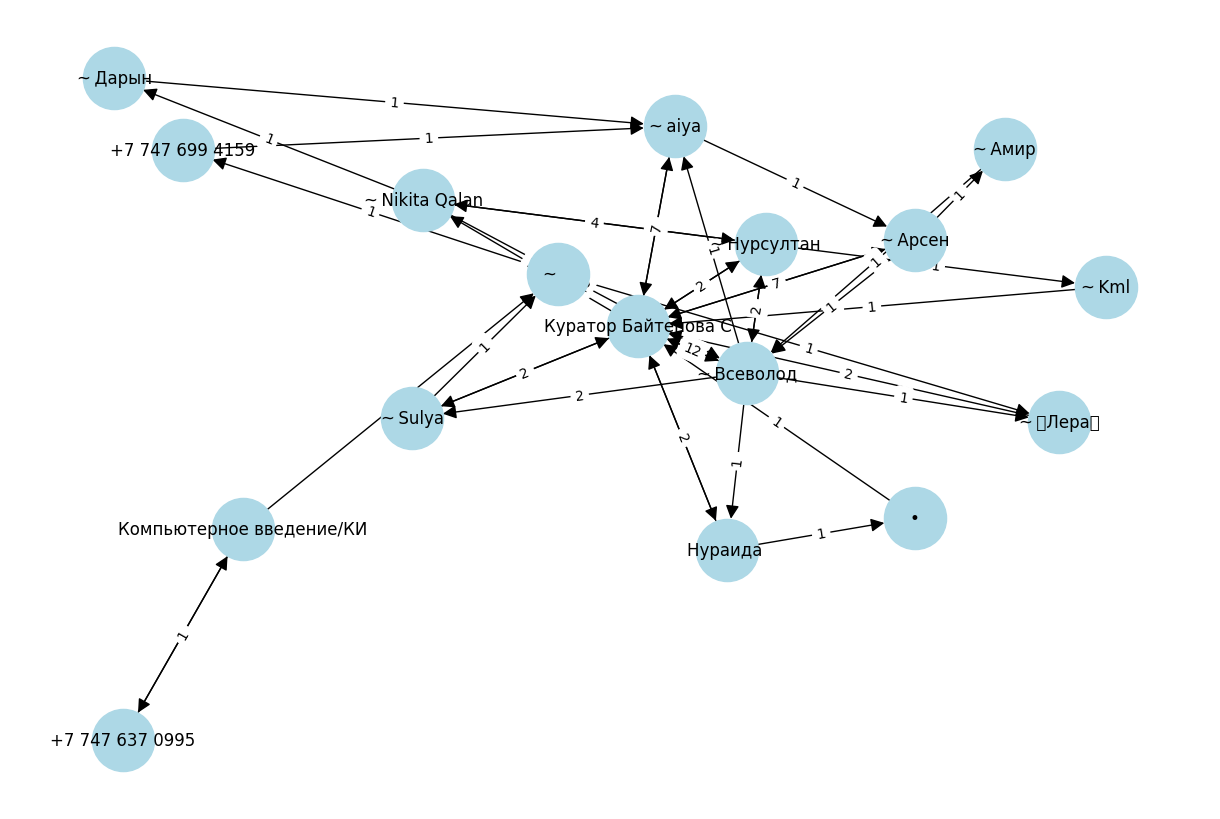

In [32]:
import networkx as nx

# добавляем предыдущего пользователя
df['prev_user'] = df['user'].shift(1)

# считаем, когда пользователь ответил другому
replies = df[df['user'] != df['prev_user']]

# таблица отношений
edges = replies.groupby(['prev_user','user']).size().reset_index(name='count')

# строим граф
G = nx.from_pandas_edgelist(edges, 'prev_user', 'user', ['count'], create_using=nx.DiGraph())

# визуализация
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', arrowsize=20)
labels = nx.get_edge_attributes(G,'count')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)
plt.show()

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# создаем векторы
vectorizer = TfidfVectorizer(max_features=500)  # можно увеличить, если сообщений много
X = vectorizer.fit_transform(df['clean'])

# KMeans
num_clusters = 5  # количество кластеров можно менять
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

# посмотрим первые 10 сообщений с кластерами
df[['user','message','cluster']].head(10)

,user,message,cluster
0,Компьютерное введение/КИ,‎Сообщения и звонки защищены сквозным шифрован...,2
1,‪+7 747 637 0995‬,‎Группа создана контактом ‪+7 747 637 0995‬,2
2,Компьютерное введение/КИ,‎~ Nikita Qalan добавил(-а) вас,2
3,~ ⠀​,‎~ ⠀​ изменил(-а) картинку группы,2
4,~ ⠀​,‎~ ⠀​ удалил(-а) картинку группы,2
5,‪+7 747 699 4159‬,‎~ Nikita Qalan удалил(-а) контакт ‪+7 747 699...,2
6,~ aiya,‎~ Nikita Qalan добавил(-а) контакт ~ aiya,2
7,Куратор Байтенова С,Добрый вечер!,2
8,Куратор Байтенова С,❗️❗️❗️❗️❗️,2
9,Куратор Байтенова С,❗️❗️❗️❗️,2


In [34]:
import numpy as np

terms = vectorizer.get_feature_names_out()  # слова из TF-IDF
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(num_clusters):
    print(f"Кластер {i}:")
    top_words = [terms[ind] for ind in order_centroids[i, :10]]  # 10 слов
    print(", ".join(top_words))
    print()

Кластер 0:
не, такого, относится, понял, зум, знаю, вижу, трубку, поднимает, нет

Кластер 1:
здравствуйте, каждого, кажется, казахского, казню, как, какие, каком, какую, камал

Кластер 2:
сделал, на, да, это, добрый, сем, вечер, вас, завтра, выбрали

Кластер 3:
прошел, естеусіз, тестирование, келсін, кейін, касымбек, картинку, камал, какую, каком

Кластер 4:
все, проверьте, должны, зарегистр, помечаны, обязательным, которые, видно, просмотрите, вроде



In [35]:
# Считаем количество сообщений каждого пользователя в каждом кластере
cluster_activity = df.groupby(['cluster','user']).size().unstack(fill_value=0)
cluster_activity

user,~ Kml,~ Nikita Qalan,~ Sulya,~ aiya,~ Амир,~ Арсен,~ Всеволод,~ Дарын,~ Нурсултан,~ ✨Лера✨,~ ⠀​,Компьютерное введение/КИ,Куратор Байтенова С,Нураида,•,‪+7 747 637 0995‬,‪+7 747 699 4159‬
cluster,,,,,,,,,,,,,,,,,
0,0,0,0,1,0,2,2,0,1,0,0,0,9,0,0,0,0
1,0,0,0,0,0,2,2,0,0,0,0,0,5,1,1,0,0
2,2,4,4,7,1,6,22,0,12,2,3,2,139,2,0,1,1
3,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,1,0,1,3,0,0,0,0,0,2,0,0,0,0


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


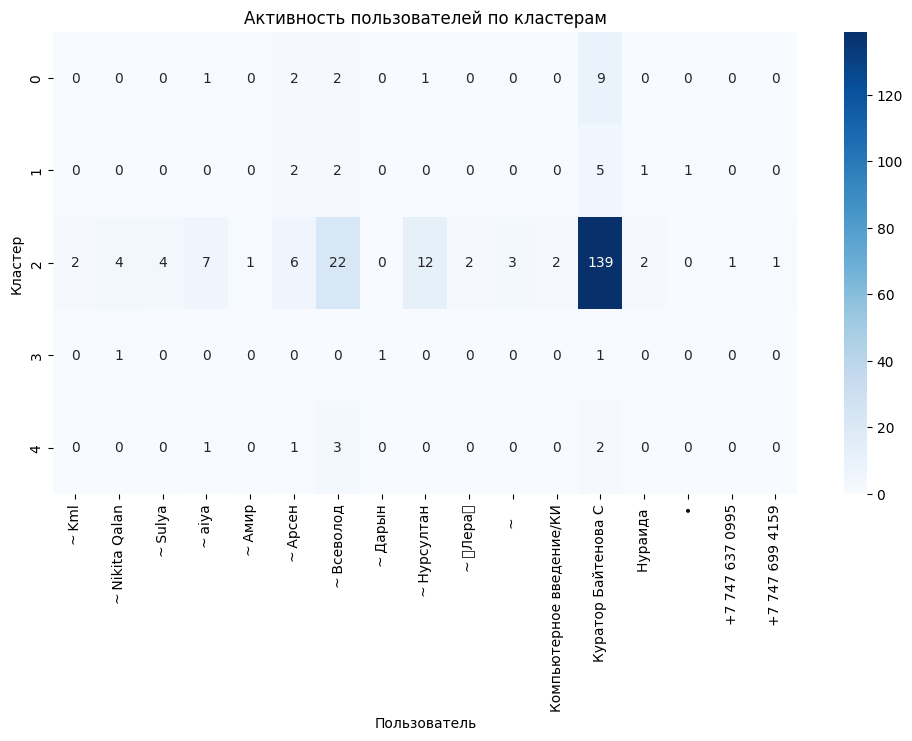

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(cluster_activity, annot=True, fmt="d", cmap="Blues")
plt.ylabel("Кластер")
plt.xlabel("Пользователь")
plt.title("Активность пользователей по кластерам")
plt.show()

In [37]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction import _stop_words

# Можно взять готовый список стоп-слов русского языка
russian_stopwords = [
    "и","в","во","не","что","он","на","я","с","со","как","а","то","все","она",
    "так","его","но","да","ты","к","у","же","вы","за","бы","по","ее","мне","было",
    "вот","от","меня","еще","нет","о","из","ему","теперь","когда","даже","ну","вдруг",
    "ли","если","уже","или","ни","быть","был","него","до","вас","нибудь","опять","уж",
    "вам","сказал","ведь","там","потом","себя","ничего","ей","может","они","тут",
    "где","есть","надо","ней","для","мы","тебя","их","чем","была","сам","чтоб","без",
    "будто","чего","раз","тоже","себе","под","будет","ж","тогда","кто","этот","того",
    "потому","этого","какой","совсем","ним","здесь","этом","один","почти","мой","тем",
    "чтобы","нее","сейчас","были","куда","зачем","всех","никогда","можно","при","наконец",
    "два","об","другой","хоть","после","над","больше","тот","через","эти","нас","про",
    "всего","них","какая","много","разве","три","эту","моя","впрочем","хорошо","свою",
    "этой","перед","иногда","лучше","чуть","том","нельзя","такой","им","более","всегда",
    "конечно","всю","между"
]

cv = CountVectorizer(max_features=500, stop_words=russian_stopwords)
X_count = cv.fit_transform(df['clean'])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_count)

terms = cv.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_words = [terms[j] for j in topic.argsort()[-10:][::-1]]
    print(f"Тема {i}: {', '.join(top_words)}\n")

Тема 0: сем, это, де, фотоотчет, киіп, келсін, деген, ұлттық, айтыңыздар, студенттерге

Тема 1: время, видео, получается, спасибо, молодцы, сулейман, должен, нурсултан, это, студенты

Тема 2: выбрали, траекторию, выбрать, должна, правильно, систем, nikita, qalan, поэзии, одну

Тема 3: здравствуйте, это, дисциплины, изменено, сообщение, пройти, компонент, вузовский, разные, относится

Тема 4: сделал, добрый, вечер, расписание, прошел, такого, проверьте, можем, удалила, кажется



In [38]:
# Получаем распределение по темам для каждого сообщения
lda_topics = lda.transform(X_count)

# Присваиваем каждой строке тему с наибольшей вероятностью
df['lda_topic'] = lda_topics.argmax(axis=1)

# Считаем, сколько сообщений каждого пользователя в каждой теме
lda_activity = df.groupby(['lda_topic','user']).size().unstack(fill_value=0)
lda_activity

user,~ Kml,~ Nikita Qalan,~ Sulya,~ aiya,~ Амир,~ Арсен,~ Всеволод,~ Дарын,~ Нурсултан,~ ✨Лера✨,~ ⠀​,Компьютерное введение/КИ,Куратор Байтенова С,Нураида,•,‪+7 747 637 0995‬,‪+7 747 699 4159‬
lda_topic,,,,,,,,,,,,,,,,,
0,1,0,1,2,0,3,8,0,2,1,1,1,43,0,0,0,0
1,0,0,0,2,0,0,4,0,2,0,0,0,28,1,0,0,0
2,0,3,0,2,0,2,5,0,2,1,0,1,23,0,0,0,0
3,0,1,2,1,0,3,7,0,3,0,1,0,35,1,1,1,0
4,1,1,1,2,1,3,5,1,4,0,1,0,27,1,0,0,1


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


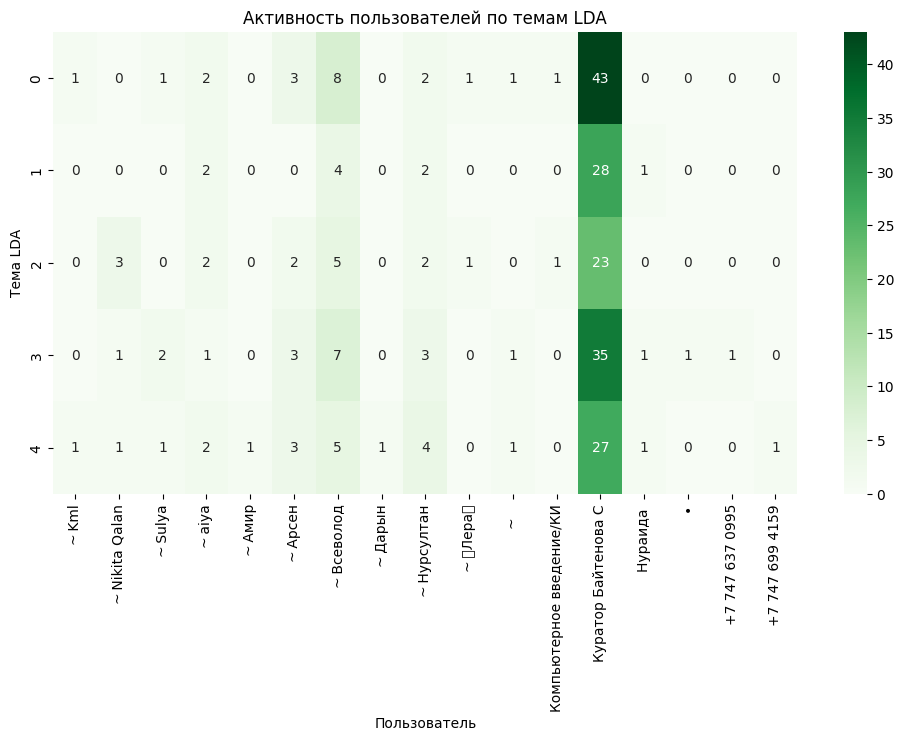

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(lda_activity, annot=True, fmt="d", cmap="Greens")
plt.ylabel("Тема LDA")
plt.xlabel("Пользователь")
plt.title("Активность пользователей по темам LDA")
plt.show()

In [41]:
# ЛЕММАТИЗАЦИЯ + СТОП-СЛОВА (фикс для Python 3.12)

!pip install pymorphy2 nltk

import inspect
import nltk
import pymorphy2
from nltk.corpus import stopwords

#  ПАТЧ для Python 3.12 (очень важно)
if not hasattr(inspect, 'getargspec'):
    inspect.getargspec = inspect.getfullargspec

nltk.download('stopwords')

morph = pymorphy2.MorphAnalyzer()

russian_stopwords = stopwords.words("russian")

def lemmatize_text(text):
    words = text.split()
    lemmas = [morph.parse(word)[0].normal_form for word in words]
    lemmas = [word for word in lemmas if word not in russian_stopwords and len(word) > 2]
    return " ".join(lemmas)

df['lemma'] = df['clean'].apply(lemmatize_text)

df[['clean','lemma']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,clean,lemma
0,сообщения и звонки защищены сквозным шифровани...,сообщение звонок защитить сквозной шифрование ...
1,группа создана контактом,группа создать контакт
2,nikita qalan добавила вас,nikita qalan добавить
3,изменила картинку группы,изменить картинка группа
4,удалила картинку группы,удалить картинка группа


In [42]:
#  КЛАСТЕРИЗАЦИЯ ПОСЛЕ ЛЕММАТИЗАЦИИ

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(df['lemma'])

kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

df[['user','message','cluster']].head()

,user,message,cluster
0,Компьютерное введение/КИ,‎Сообщения и звонки защищены сквозным шифрован...,0
1,‪+7 747 637 0995‬,‎Группа создана контактом ‪+7 747 637 0995‬,0
2,Компьютерное введение/КИ,‎~ Nikita Qalan добавил(-а) вас,0
3,~ ⠀​,‎~ ⠀​ изменил(-а) картинку группы,0
4,~ ⠀​,‎~ ⠀​ удалил(-а) картинку группы,0


In [43]:
#  СЛОВА КАЖДОГО КЛАСТЕРА

terms = vectorizer.get_feature_names_out()

for i in range(5):
    center = kmeans.cluster_centers_[i]
    words = [terms[ind] for ind in center.argsort()[-10:]]
    print(f"\nКластер {i}:")
    print(", ".join(words))


Кластер 0:
вечер, траектория, добрый, должный, весь, система, сем, выбрать, это, сделать

Кластер 1:
киіп, киімімізді, киімді, кинотеатр, кеші, керемета, керека, келсін, келген, здравствуйте

Кластер 2:
аккомпанемент, поэзия, акын, орь, играть, видео, соревноваться, вдвоём, хороший, тип

Кластер 3:
который, вечером, след, год, хотеть, тестирование, естеусіз, дисциплина, физика, пройти

Кластер 4:
скрин, делать, вроде, должный, помечан, видно, просмотреть, зарегистр, проверить, всё


In [44]:
#LDA ПОСЛЕ ЛЕММАТИЗАЦИИ

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=500)
X_count = cv.fit_transform(df['lemma'])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_count)

LatentDirichletAllocation(n_components=5, random_state=42)

In [45]:
#ВЫВОД ТЕМ

words = cv.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"\nТема {i}:")
    print(", ".join([words[i] for i in topic.argsort()[-10:]]))


Тема 0:
факультет, деген, ұлттық, келсін, киіп, акын, поэзия, мочь, сделать, это

Тема 1:
спасибо, зарегистрироваться, вариант, знать, правильно, весь, сем, траектория, должный, выбрать

Тема 2:
след, год, завтра, вузовский, компонент, обязательный, система, это, дисциплина, пройти

Тема 3:
добавить, контакт, проверить, фотоотчёт, qalan, nikita, мочь, вечер, добрый, здравствуйте

Тема 4:
нужно, скинуть, семестр, выбрать, изменить, система, группа, выбирать, студент, всё


In [48]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Создаем метрики для каждого человека
user_features = df.groupby('user').agg({
    'message': 'count',
    'clean': lambda x: x.str.len().mean() # средняя длина сообщения
}).fillna(0)

# Масштабируем и делим на 3 кластера
scaler = StandardScaler()
data_scaled = scaler.fit_transform(user_features)
kmeans = KMeans(n_clusters=3, random_state=42).fit(data_scaled)
user_features['cluster'] = kmeans.labels_

print("Распределение пользователей по кластерам активности:")
print(user_features)

Распределение пользователей по кластерам активности:
                          message      clean  cluster
user                                                 
~ Kml                           2  29.500000        0
~ Nikita Qalan                  5  19.000000        0
~ Sulya                         4  52.500000        2
~ aiya                          9  19.666667        0
~ Амир                          1   6.000000        0
~ Арсен                        11  12.181818        0
~ Всеволод                     29  20.344828        0
~ Дарын                         1   6.000000        0
~ Нурсултан                    13  45.769231        2
~ ✨Лера✨                        2  19.000000        0
~ ⠀​                            3  17.666667        0
Компьютерное введение/КИ        2  72.500000        1
Куратор Байтенова С           156  24.083333        0
Нураида                         3  21.666667        0
•                               1  12.000000        0
‪+7 747 637 0995‬            